In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")  # makes all plots look clean

df = pd.read_csv("../data/clean_listings.csv")
print(df.shape)
df.head()

(467, 9)


,title,type,location,bedrooms,bathrooms,price_qar,area_sqm,district,city
0,Modern 3 BHK APT | Fully Furnished | In Al Man...,Apartment,"Al Mansoura, Al Mansoura, Doha",3.0,3.0,7000,200.0,Al Mansoura,Doha
1,Bills Included | Luxury 1 Bedroom | No Commission,Apartment,"Lusail Residence, Marina District, Lusail",1.0,2.0,7569,86.0,Marina District,Lusail
2,LUXURY 2BR | MARINA VIEW | PORTO ARABIA | For ...,Apartment,"East Porto Drive, Porto Arabia, The Pearl Isla...",2.0,3.0,10000,175.0,The Pearl Island,Doha
3,LUSAIL NEW 1BHK FURNISHED SHORT TERM RENT NO FEE,Apartment,"Al Erkyah City, Lusail",1.0,2.0,5500,60.0,Al Erkyah City,Lusail
4,"LUSAIL 1BHK SHORT TERM OPTION BILLS INCL, POOL...",Apartment,"Al Erkyah City, Lusail",1.0,2.0,5500,60.0,Al Erkyah City,Lusail


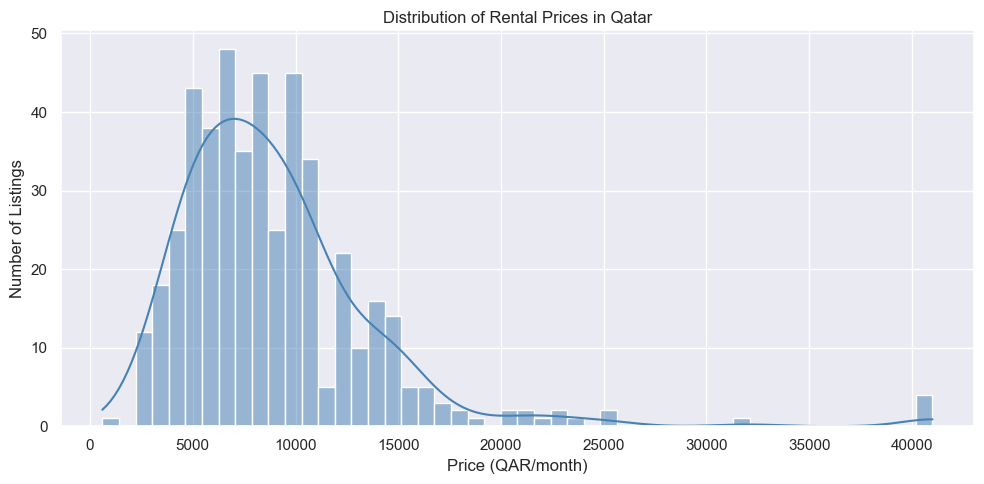

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price_qar"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Rental Prices in Qatar")
plt.xlabel("Price (QAR/month)")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig("../data/price_distribution.png")
plt.show()

/var/folders/fq/8xpw3j0d0bj0pk57kxzbfdcc0000gn/T/ipykernel_89126/2640894022.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_avg.values, y=district_avg.index, palette="viridis")


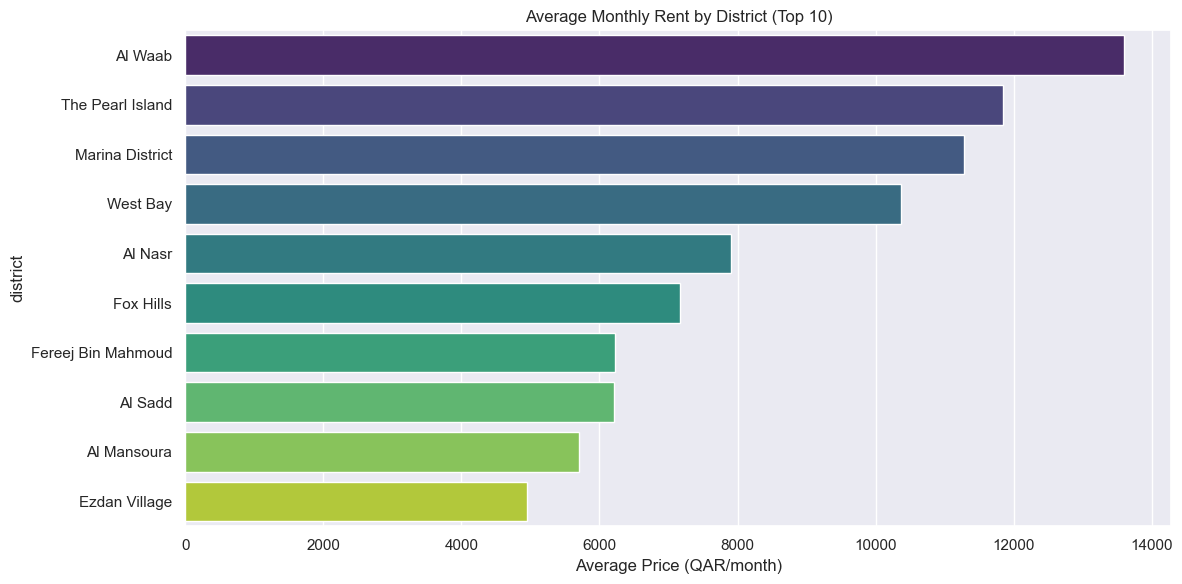

In [13]:
top_districts = df["district"].value_counts().head(10).index

district_avg = (
    df[df["district"].isin(top_districts)]
    .groupby("district")["price_qar"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=district_avg.values, y=district_avg.index, palette="viridis")
plt.title("Average Monthly Rent by District (Top 10)")
plt.xlabel("Average Price (QAR/month)")
plt.tight_layout()
plt.savefig("../data/avg_price_by_district.png")
plt.show()

In [14]:
# Check what the outliers look like
print(df["price_qar"].describe())
print("---")
print(df["area_sqm"].describe())

count      467.000000
mean      8996.569593
std       5063.669593
min        599.000000
25%       5540.000000
50%       8000.000000
75%      10625.000000
max      41000.000000
Name: price_qar, dtype: float64
---
count    467.000000
mean     148.233405
std       96.799221
min        1.000000
25%       92.500000
50%      120.000000
75%      165.000000
max      651.000000
Name: area_sqm, dtype: float64


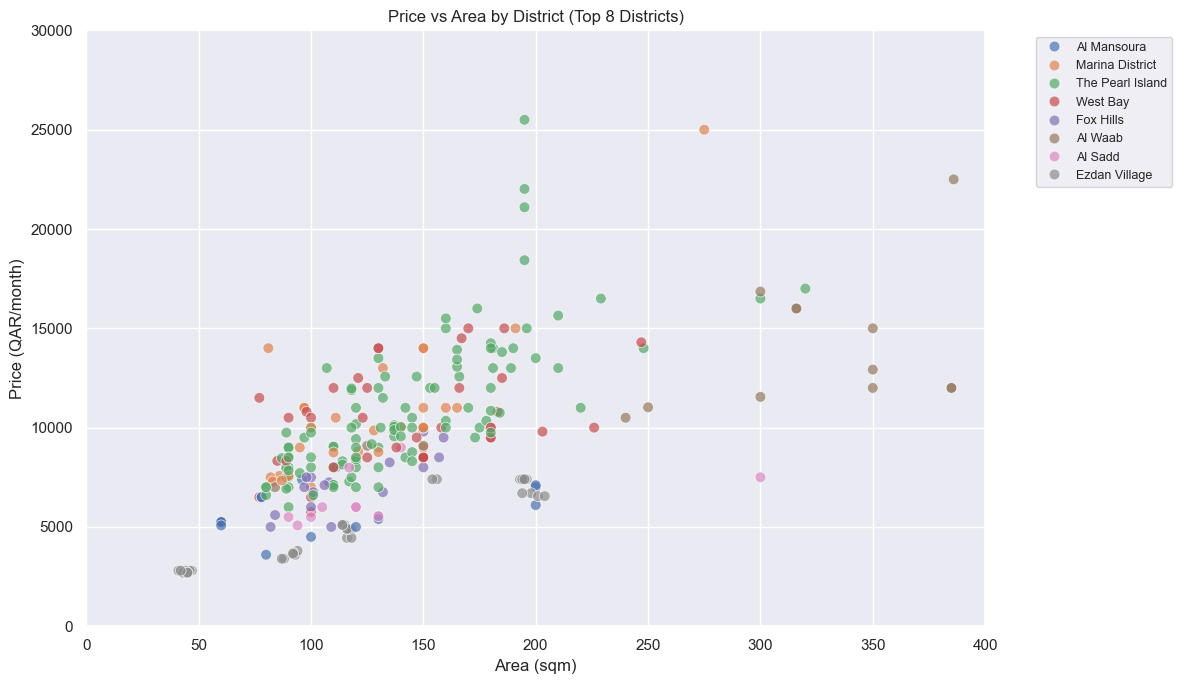

In [15]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df[df["district"].isin(df["district"].value_counts().head(8).index)],
    x="area_sqm", y="price_qar",
    hue="district", alpha=0.7, s=60
)
plt.title("Price vs Area by District (Top 8 Districts)")
plt.xlabel("Area (sqm)")
plt.ylabel("Price (QAR/month)")
plt.ylim(0, 30000)
plt.xlim(0, 400)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../data/price_vs_area.png")
plt.show()

/var/folders/fq/8xpw3j0d0bj0pk57kxzbfdcc0000gn/T/ipykernel_89126/3241755427.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="bedrooms", palette="Set2", order=sorted(df["bedrooms"].dropna().unique()))


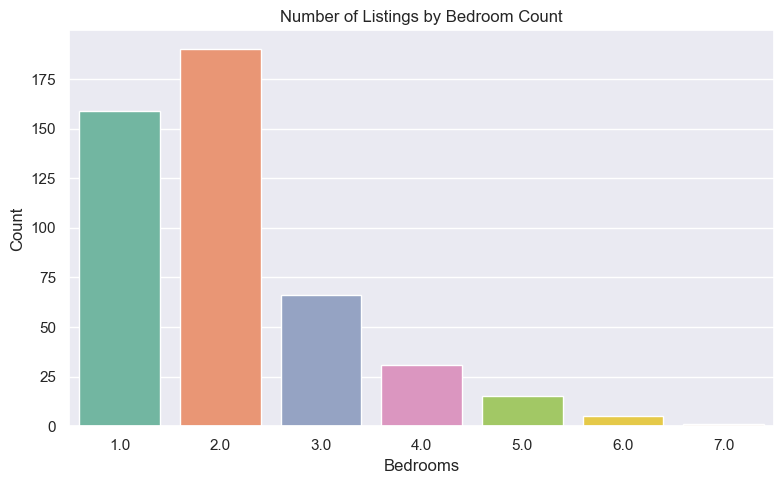

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="bedrooms", palette="Set2", order=sorted(df["bedrooms"].dropna().unique()))
plt.title("Number of Listings by Bedroom Count")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../data/bedroom_distribution.png")
plt.show()